# Custom Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/03-building-models/custom_models.ipynb)

Testing a model that isn't in the literature — or is, but isn't one
of CosmoFit's twenty built-ins — doesn't require touching the
library's internals. There are three routes, in increasing order of
how much control they give:

| route | you supply | good for |
|---|---|---|
| `model_from_expression` | `E(z)` as a **string** | a quick idea, a text box, a GUI |
| `define_model` | `E(z)` as a **function** | anything numpy can express |
| subclassing `Cosmology` | methods on a class | a model with internal state or a solve |

All three produce an ordinary model: every dataset, likelihood,
sampler and plot works on it unchanged.

If you have the *action* rather than `E(z)`, see
[`models_from_an_action.ipynb`](models_from_an_action.ipynb) — that
does the variational calculus for you.

## Setup

In [ ]:
import sys

# On Colab, install the released package and nothing else.
#
# This used to clone the repository and install it editable,
# which needed a `sys.path` fix afterwards: pip runs in a
# subprocess, so the already-running kernel never saw the .pth
# file it wrote, and `import CosmoFit` could resolve to the bare
# checkout directory instead -- same name, and /content is on
# sys.path. A normal install goes to site-packages, which is
# already there, so all of that goes away.

if "google.colab" in sys.modules:
    !pip install -q cosmofit
else:
    print("Not running in Colab -- assuming CosmoFit is already "
          'installed (pip install cosmofit).')


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import Cosmology, Fitter, LCDM, define_model, model_from_expression

plt.rcParams["figure.dpi"] = 110

## 1. From a string

The shortest route. `E` is a Python expression seeing `z`, every
standard parameter (`H0`, `Omega_m`, `Omega_k`, `w0`, `wa`, `rd`,
...) and anything declared in `extra_params`, plus a small set of
elementwise numpy functions.

Here is a dark-energy density that grows linearly with `z` on top of
a constant `w`:

$$E^2 = \Omega_m(1+z)^3 + (1-\Omega_m)(1+z)^{3(1+w_0)}(1+\beta z)$$

In [3]:
Linear = model_from_expression(
    "LinearDE",
    E="sqrt(Omega_m*(1+z)**3 + (1-Omega_m)*(1+z)**(3*(1+w0))*(1+beta*z))",
    extra_params={
        # Keep 1 + beta*z positive across the data's redshift range:
        # outside that the dark-energy density turns negative, which
        # is a different (and much more interesting) model than the
        # one this cell is illustrating.
        "beta": {"default": 0.0, "bounds": (-0.3, 0.3), "label": r"$\beta$"},
    },
    label=r"linear-$\beta$ DE",
)

m = Linear(Linear.PARAMS_CLASS(H0=70.0, Omega_m=0.3, w0=-1.0, beta=0.2))
print(f"{Linear.plain_name()} / {Linear.plot_label()}")
print("E(0), E(1), E(2) =", np.round(m.E([0.0, 1.0, 2.0]), 6))

LinearDE / linear-$\beta$ DE
E(0), E(1), E(2) = [1.       1.8      3.013304]


`extra_params` declares anything beyond the standard set: a
`default`, prior `bounds` (needed only if it will be fit), and an
optional LaTeX `label` for corner plots.

The expression is evaluated with `eval()`, but with builtins removed
and only elementwise numpy functions in scope. That is a convenience
for trusted local use — a GUI text box on your own machine — not a
sandbox for untrusted input.

## 2. From a function

Same thing, but `E` is a callable taking `(params_dict, z)`. Worth it
as soon as the expression stops fitting comfortably on one line, or
needs anything numpy can do but a single expression cannot.

In [4]:
def E_linear(p, z):
    one_plus_z = 1.0 + z
    matter = p["Omega_m"] * one_plus_z**3
    dark = (1.0 - p["Omega_m"]) * one_plus_z ** (3 * (1 + p["w0"]))
    return np.sqrt(matter + dark * (1.0 + p["beta"] * z))


LinearFn = define_model(
    "LinearDE",
    E=E_linear,
    extra_params={"beta": {"default": 0.0, "bounds": (-0.3, 0.3)}},
)

same = LinearFn(LinearFn.PARAMS_CLASS(H0=70.0, Omega_m=0.3, w0=-1.0, beta=0.2))
print("agrees with the string version:",
      np.allclose(same.E([0.0, 1.0, 2.0]), m.E([0.0, 1.0, 2.0])))

agrees with the string version: True


`E(z)` alone is enough to fit against every dataset and produce
every plot except `w_of_z()` and `deceleration()`. Those need `w`
and `dEdz`, which can be passed the same way — and if `dEdz` is
omitted, a central finite difference is installed so
`deceleration()` still works:

In [5]:
WithW = define_model(
    "LinearDE",
    E=E_linear,
    w=lambda p, z: p["w0"] + 0.0 * z,        # constant, for this example
    extra_params={"beta": {"default": 0.0, "bounds": (-0.3, 0.3)}},
)

mm = WithW(WithW.PARAMS_CLASS(H0=70.0, Omega_m=0.3, w0=-0.9, beta=0.1))
print("w(z) =", np.round(mm.w([0.0, 1.0]), 4))
print("dEdz(1) from the finite-difference fallback =", round(float(mm.dEdz(1.0)), 8))

w(z) = [-0.9 -0.9]
dEdz(1) from the finite-difference fallback = 1.04614824


## 3. By subclassing

`define_model` is a thin wrapper around declaring `EXTRA_PARAMS` on
a `Cosmology` subclass. Doing it directly is what you want when the
model needs internal state, a cached solve, or several methods that
share work.

In [6]:
class LinearDE(Cosmology):
    """Dark energy with a linearly growing density."""

    MODEL_NAME = "LinearDE"
    MODEL_LABEL = r"linear-$\beta$ DE"

    EXTRA_PARAMS = {
        "beta": {"default": 0.0, "bounds": (-0.3, 0.3), "label": r"$\beta$"},
    }

    def _dark(self, z):
        return (1.0 - self.Omega_m) * (1.0 + z) ** (3 * (1 + self.w0)) * (
            1.0 + self.beta * z
        )

    def E(self, z):
        z = np.asarray(z, dtype=float)
        return np.sqrt(self.Omega_m * (1.0 + z) ** 3 + self._dark(z))

    def dEdz(self, z, h=1e-5):
        # Required for a direct subclass -- see the note below.
        z = np.asarray(z, dtype=float)
        return (self.E(z + h) - self.E(z - h)) / (2.0 * h)

    def Omega_de(self, z):
        return self._dark(np.asarray(z, dtype=float))


sub = LinearDE(LinearDE.PARAMS_CLASS(H0=70.0, Omega_m=0.3, w0=-1.0, beta=0.2))
print("all three routes agree:",
      np.allclose(sub.E([0.0, 1.0, 2.0]), m.E([0.0, 1.0, 2.0])))

all three routes agree: True


Note `self.beta` works without being declared anywhere else:
`__init_subclass__` builds a parameter dataclass from `EXTRA_PARAMS`
and installs a property for each entry.

### A direct subclass must define `dEdz`

And from the moment it is *constructed*, not just when a plot asks
for it. The distance integrator interpolates `1/E(z)` with a Hermite
spline built from that derivative, which is what makes it exact to
fourth order instead of second — so it is needed before anything
else happens.

`define_model` and `model_from_expression` install a
central-difference fallback for you. Subclassing deliberately does
not, so that a model can supply the *exact* derivative — as every
built-in model does — rather than silently give up about four orders
of magnitude of accuracy in every distance. Leave it out and you get
told:

In [7]:
from CosmoFit import Cosmology as _Cosmology


class Incomplete(_Cosmology):
    def E(self, z):
        z = np.asarray(z, dtype=float)
        return np.sqrt(self.Omega_m * (1.0 + z) ** 3 + 1.0 - self.Omega_m)


try:
    Incomplete(Incomplete.PARAMS_CLASS(H0=70.0, Omega_m=0.3))
except NotImplementedError as exc:
    print(exc)

Incomplete does not define dEdz(z).
A model written by subclassing `Cosmology` directly has to, and from the moment it is constructed: the distance integrator interpolates 1/E(z) with a Hermite spline built from this derivative, which is what makes it exact to fourth order rather than second. A finite difference would quietly cost about four orders of magnitude of accuracy in every distance, so it is not substituted silently.
Either write it out -- it is one line of calculus beside E(z), and every built-in model does -- or use cosmology.custom.define_model, which installs a central-difference fallback for exactly the cases where deriving it by hand is not worth it.


## 4. Modified gravity: `mu(a, k)`

A model that only reparametrizes dark energy leaves gravity alone,
and growth-of-structure predictions follow from `E(z)` — that is the
default, `mu = 1`.

A genuinely modified-gravity model changes the effective coupling in
the linear growth equation, and says so through `mu`. It takes the
scale factor `a` and a wavenumber `k` in h/Mpc (or `None`, for a
scale-independent `mu`).

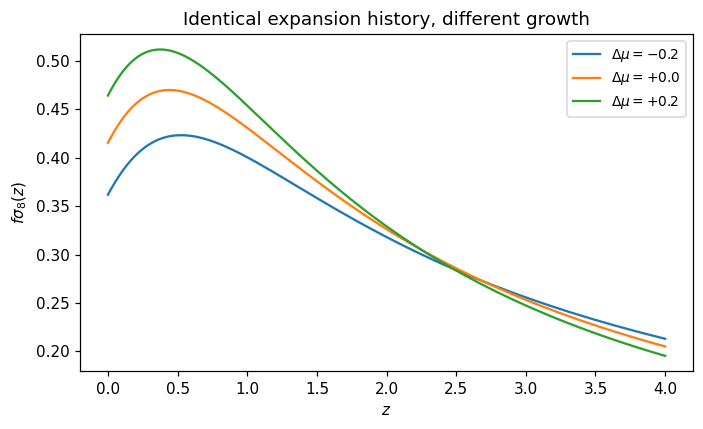

In [8]:
ModifiedGravity = model_from_expression(
    "ScaleFreeMG",
    E="sqrt(Omega_m*(1+z)**3 + (1-Omega_m))",   # LCDM background
    mu="1 + mg",                                # constant boost to G_eff
    extra_params={"mg": {"default": 0.0, "bounds": (-0.3, 0.3),
                         "label": r"$\Delta\mu$"}},
)

a = np.linspace(0.2, 1.0, 200)
fig, ax = plt.subplots(figsize=(6.5, 4))

for mg in (-0.2, 0.0, 0.2):
    g = ModifiedGravity(ModifiedGravity.PARAMS_CLASS(
        H0=70.0, Omega_m=0.3, sigma8=0.81, mg=mg))
    ax.plot(1 / a - 1, g.background.fsigma8(1 / a - 1),
            label=rf"$\Delta\mu = {mg:+.1f}$")

ax.set_xlabel("$z$")
ax.set_ylabel(r"$f\sigma_8(z)$")
ax.set_title("Identical expansion history, different growth")
ax.legend(fontsize=9)
fig.tight_layout()

Same `E(z)` in all three curves — the background cannot tell them
apart, and only growth data can. That is the whole reason
`fsigma8`/`s8` exist as separate datasets.

## 5. Fitting one

Nothing special: a custom model goes into `Fitter` like any other.

In [9]:
fit = Fitter(
    model=Linear,
    datasets=["cc", "desi", "pantheon"],
    free_params=["H0", "Omega_m", "w0", "beta", "rd"],
    initial={"H0": 70.0, "Omega_m": 0.3, "w0": -1.0, "beta": 0.0,
             "rd": 147.0},
)

best = fit.best_fit(restarts=3, seed=0)
for name, value in zip(fit.free_params, best.x):
    print(f"  {name:8s} = {value: .4f}")
print(f"\n  chi2 = {best.fun:.3f}")

  H0       =  70.1809
  Omega_m  =  0.3007
  w0       = -0.8687
  beta     = -0.1381
  rd       =  142.5645
  chi2 = 1481.757


In [10]:
fit.run_mcmc(nwalkers=32, nsteps=3000, burnin=600, seed=0, progress=True)
print(fit.result)

  0%|          | 0/3000 [00:00<?, ?it/s]


  0%|          | 4/3000 [00:00<01:28, 33.76it/s]


  0%|          | 8/3000 [00:00<01:32, 32.52it/s]


  0%|          | 12/3000 [00:00<01:27, 34.33it/s]


  1%|          | 16/3000 [00:00<01:27, 34.29it/s]


...

100%|█████████▉| 2994/3000 [01:15<00:00, 42.05it/s]


100%|█████████▉| 2999/3000 [01:15<00:00, 43.37it/s]


100%|██████████| 3000/3000 [01:15<00:00, 39.59it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 48;
tau: [58.15688098 66.61805359 68.332483   70.4517204  57.92763252]


FitResult(model=LinearDE, datasets=['cc', 'desi', 'pantheon'], free_params=['H0', 'Omega_m', 'w0', 'beta', 'rd'])
  BestFitResult(H0=70.1809, Omega_m=0.300657, w0=-0.868718, beta=-0.138114, rd=142.565, chi2=1481.7574, AIC=1491.76, BIC=1518.85)
  MCMCResult(32 walkers x 3000 steps, burnin=600, NOT converged, acceptance=0.49)
  H0 = 68.2974 (+3.2/-3.1)
  Omega_m = 0.29919 (+0.015/-0.015)
  w0 = -0.900765 (+0.069/-0.079)
  beta = -0.038814 (+0.21/-0.18)
  rd = 146.309 (+6.7/-6.5)


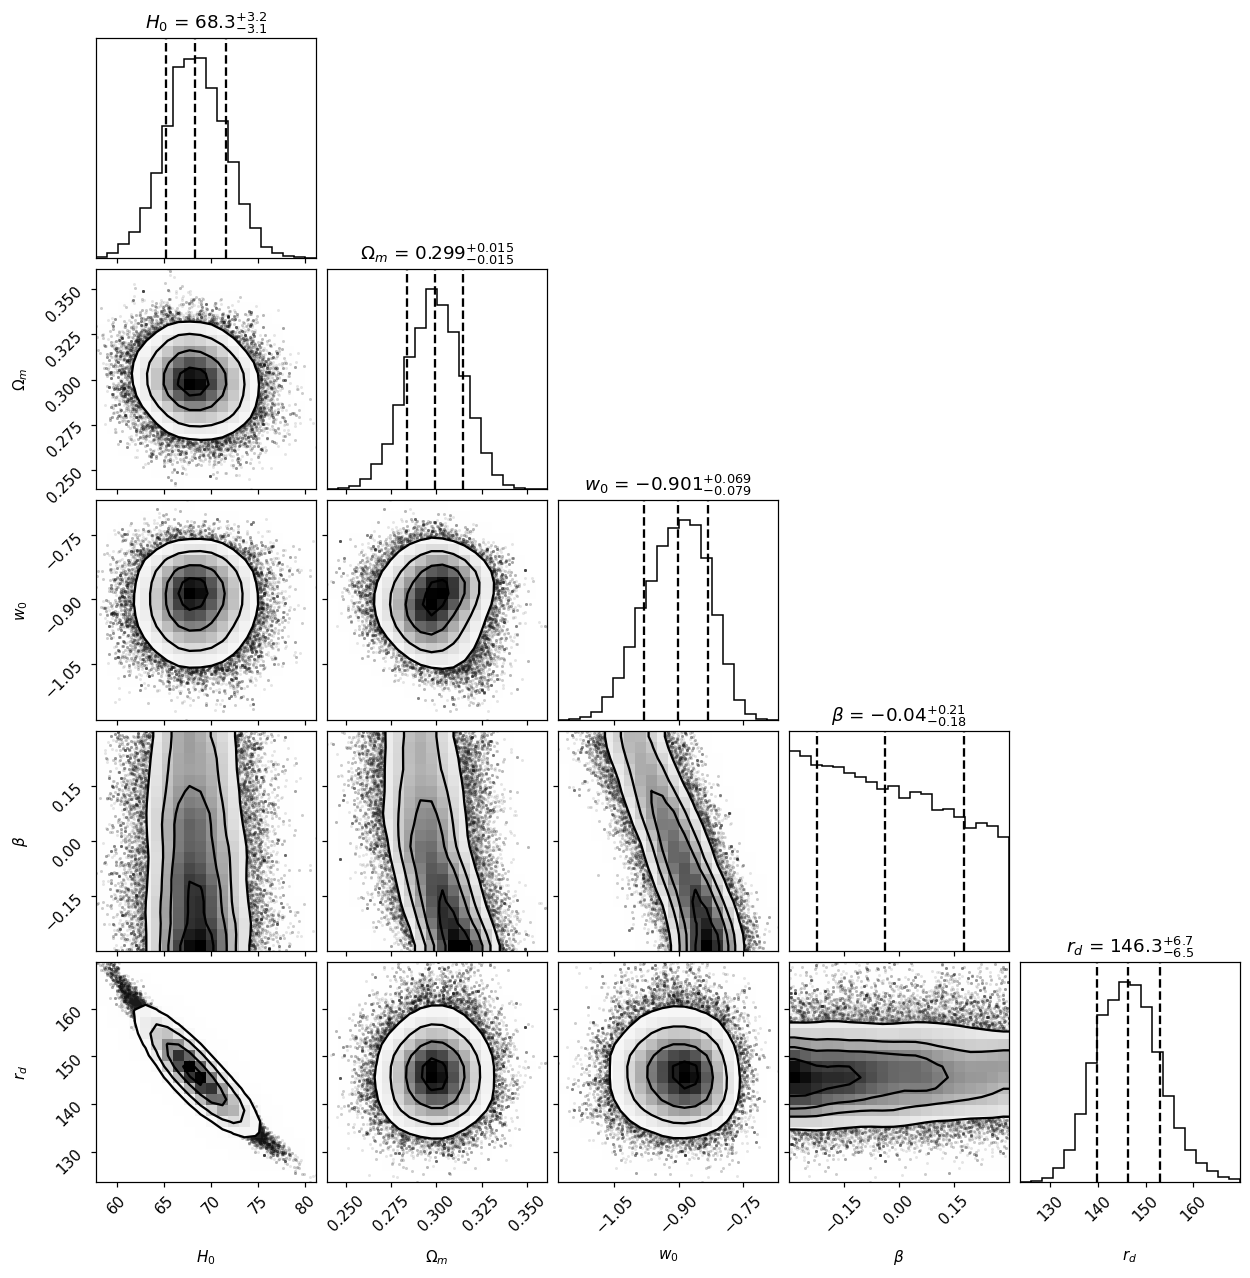

In [11]:
fit.plots.corner();

### Is the extra freedom earned?

`beta = 0` and `w0 = -1` together is ΛCDM, so the comparison is
nested and a likelihood-ratio test applies.

In [12]:
from CosmoFit.stats.model_comparison import compare_models, likelihood_ratio_test

reference = Fitter(
    model=LCDM,
    datasets=["cc", "desi", "pantheon"],
    free_params=["H0", "Omega_m", "rd"],
    initial={"H0": 70.0, "Omega_m": 0.3, "rd": 147.0},
)
ref_best = reference.best_fit(restarts=3, seed=0)

comparison = compare_models(
    name_null="LCDM",
    chi2_null=ref_best.fun,
    k_null=len(reference.free_params),
    name_alt="LinearDE",
    chi2_alt=best.fun,
    k_alt=len(fit.free_params),
    n_data=fit.n_data,
)

for model in ("LCDM", "LinearDE"):
    row = comparison[model]
    print(f"  {model:10s} chi2={row['chi2']:8.3f}  k={row['k']}  "
          f"AIC={row['AIC']:8.3f}  BIC={row['BIC']:8.3f}")

print(f"\n  delta_AIC = {comparison['delta_AIC']:+.3f}   "
      f"(positive favours LinearDE)")
print(f"  delta_BIC = {comparison['delta_BIC']:+.3f}")

  LCDM       chi2=1485.196  k=3  AIC=1491.196  BIC=1507.454
  LinearDE   chi2=1481.757  k=5  AIC=1491.757  BIC=1518.854
  delta_AIC = -0.561   (positive favours LinearDE)
  delta_BIC = -11.400


In [13]:
lrt = comparison["likelihood_ratio_test"]
for key, value in lrt.items():
    print(f"  {key:12s} = {value}")

print("\nBoth extra parameters together are the test: beta = 0 and")
print("w0 = -1 is exactly LCDM, so this comparison is nested and the")
print("chi-squared distribution applies.")

  delta_chi2   = 3.4386488786913105
  delta_k      = 2
  p_value      = 0.1791871588260513
  sigma        = 0.9184672106788061
Both extra parameters together are the test: beta = 0 and
w0 = -1 is exactly LCDM, so this comparison is nested and the
chi-squared distribution applies.


## Which route to use

- **A string** if the model is one line and you want it fast, or if
  it has to come from a text box.
- **A function** for anything else expressible in numpy.
- **A subclass** when the model has internal state — a spline it
  builds once, an ODE it solves, a parameter it derives. Every
  built-in model beyond the simple parametrizations is written this
  way; `HDE`, `ADE` and `RDE` in
  [`../02-models/holographic_family.ipynb`](../02-models/holographic_family.ipynb)
  are good examples.
- **An action**, in
  [`models_from_an_action.ipynb`](models_from_an_action.ipynb), when
  you have a Lagrangian and would rather not derive `E(z)` by hand
  at all.